<a href="https://colab.research.google.com/github/eng20260311/AIFFEL_quest_eng/blob/master/NLP/NLP04/Bert_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
# imports
from __future__ import absolute_import, division, print_function, unicode_literals

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchsummary import summary

import os
import re
import math
import numpy as np
import pandas as pd
import random
import collections
import json
import shutil
import zipfile
import copy
from datetime import datetime

import matplotlib.pyplot as plt
import sentencepiece as spm
from tqdm.notebook import tqdm

random_seed = 1234
random.seed(random_seed)
np.random.seed(random_seed)

# torch version
print(torch.__version__)

2.10.0+cu128


In [29]:
# ============================================================
# 1. Tokenizer 준비: SentencePiece 모델 학습
#  - 코퍼스: 한글 위키/나무위키 (kowiki.txt)
#  - vocab_size: 8000 + 특수토큰 7개 = 8007
#  - 모델 타입: BPE
#  - BERT 특수문자: [PAD], [UNK], [BOS], [EOS], [SEP], [CLS], [MASK]
# 이미 학습된 모델 파일이 있으면 재학습을 건너뜁니다.
# (시간이 부족하면 클라우드/LMS에 저장된 모델을 사용)
# ============================================================
import sentencepiece as spm
import os
from pathlib import Path

data_dir = Path('data')
data_dir.mkdir(parents=True, exist_ok=True)

corpus_file = data_dir / 'kowiki.txt'
prefix = data_dir / 'ko_8000'      # 출력 모델 prefix
vocab_size = 8000                  # 실제 어휘 수 (특수토큰 제외)

# 이미 학습된 모델 파일이 있으면 재사용
existing = None
for cand in [data_dir / 'ko_8000.model',
             Path('models/ko_8000.model'),
             data_dir / 'ko_32000.model',
             Path('models/ko_32000.model')]:
    if cand.exists():
        existing = cand
        break

if existing is not None:
    print(f"이미 학습된 SentencePiece 모델을 사용합니다: {existing}")
else:
    if not corpus_file.exists():
        raise FileNotFoundError(
            f"코퍼스 파일이 없습니다: {corpus_file}\n"
            "kowiki.txt 를 data/ 폴더에 준비해주세요."
        )

    print(f"SentencePiece 학습 시작 (vocab_size={vocab_size + 7})")
    spm.SentencePieceTrainer.train(
        f"--input={corpus_file} "
        f"--model_prefix={prefix} "
        f"--vocab_size={vocab_size + 7} "
        "--model_type=bpe "
        "--max_sentence_length=999999 "
        # BERT 특수 토큰 (id 고정)
        "--pad_id=0 --pad_piece=[PAD] "
        "--unk_id=1 --unk_piece=[UNK] "
        "--bos_id=2 --bos_piece=[BOS] "
        "--eos_id=3 --eos_piece=[EOS] "
        "--user_defined_symbols=[SEP],[CLS],[MASK] "
        "--hard_vocab_limit=false "
        "--character_coverage=0.9995 "
        "--input_sentence_size=1000000 "
        "--shuffle_input_sentence=true"
    )
    print(f"학습 완료: {prefix}.model, {prefix}.vocab")


이미 학습된 SentencePiece 모델을 사용합니다: data/ko_8000.model


In [30]:
data_dir = 'data'

# vocab loading: ko_8000.model을 우선 찾고, 없으면 ko_32000.model 사용
vocab = spm.SentencePieceProcessor()
for cand in [f"{data_dir}/ko_8000.model", "models/ko_8000.model",
             f"{data_dir}/ko_32000.model", "models/ko_32000.model"]:
    if os.path.exists(cand):
        vocab.load(cand)
        print(f"Loaded SentencePiece model: {cand}")
        break
else:
    raise FileNotFoundError("SentencePiece 모델을 찾을 수 없습니다. 위 셀을 먼저 실행하세요.")

print("vocab size:", vocab.get_piece_size())
print()
print("[BERT 특수 토큰 확인]")
for tok in ["[PAD]", "[UNK]", "[BOS]", "[EOS]", "[SEP]", "[CLS]", "[MASK]"]:
    print(f"  {tok:<7s} -> id = {vocab.piece_to_id(tok)}")


Loaded SentencePiece model: data/ko_8000.model
vocab size: 8007

[BERT 특수 토큰 확인]
  [PAD]   -> id = 0
  [UNK]   -> id = 1
  [BOS]   -> id = 2
  [EOS]   -> id = 3
  [SEP]   -> id = 4
  [CLS]   -> id = 5
  [MASK]  -> id = 6


In [31]:
#Q. 특수 token 7개를 제외한 나머지 token들을 출력해봅시다.
vocab_list = []
for id in range(7, len(vocab)):
        if not vocab.is_unknown(id):
            vocab_list.append(vocab.id_to_piece(id))
print(vocab_list)

['▁이', '▁1', '으로', '▁있', '에서', '▁그', '▁대', '▁사', '▁2', '▁수', '었다', '▁지', '하였', '▁가', '▁전', '▁기', '▁19', '▁시', '▁한', '이다', '▁있다', '▁정', '▁아', '▁일', '▁중', '하는', '했다', '▁주', '▁것', '하였다', '▁다', '▁제', '▁자', '하고', '▁인', '00', '▁유', '▁공', '▁하', '되었다', '▁등', '▁위', '▁경', '▁조', '▁보', '하여', '▁부', '▁나', '▁동', '▁국', '에는', '▁3', '▁의', '▁비', '으며', '▁연', '▁세', '▁발', '▁모', '▁고', '▁개', '▁영', '▁소', '▁서', '▁때', '한다', '▁미', '▁구', '▁상', '▁도', '▁오', '▁선', '▁성', '▁해', '▁신', '▁교', '▁관', '▁여', '▁마', '▁후', '▁않', '▁4', '▁만', '▁대한', '부터', '▁통', '▁내', '▁문', '지만', '적인', '▁있는', '에게', '▁거', '▁또', '되어', '적으로', '▁무', '▁반', '이라', '▁5', '▁방', '▁바', '▁남', '▁강', '▁200', '▁당', '▁프', '▁생', '들은', '▁스', '들이', '▁결', '▁"', '▁장', '까지', '▁불', '▁원', '▁같', '▁현', '▁20', '된다', '▁따', '▁계', '▁최', '▁노', '▁없', '▁분', '▁알', '▁어', '▁우', '▁실', "▁'", '▁받', '▁6', '▁독', '면서', '하기', '▁역', '▁명', '에서는', '▁많', '▁포', '▁이후', '▁한다', '▁사용', '▁진', '하게', '▁말', '▁김', '으나', '▁단', '주의', '되었', '▁두', '학교', '▁작', '▁파', '▁18', '▁7', '▁일본', '▁예', '▁그는', '▁재', '▁8'

In [32]:
# [CLS], tokens a, [SEP], tokens b, [SEP] 형태의 token 생성
string_a = "추적추적 비가 내리는 날이었어 그날은 왠지 손님이 많아 첫 번에 삼십 전 둘째번 오십 전 오랜만에 받아보는 십 전짜리 백통화 서푼에"
string_b = "손바닥 위엔 기쁨의 눈물이 흘러 컬컬한 목에 모주 한잔을 적셔 몇 달 포 전부터 콜록거리는 아내 생각에 그토록 먹고 싶다던"
tokens_org = ["[CLS]"] + vocab.encode_as_pieces(string_a) + ["[SEP]"] + vocab.encode_as_pieces(string_b) + ["[SEP]"]
print(tokens_org)

['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘러', '▁', '컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내', '▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던', '[SEP]']


In [33]:
print(tokens_org)

# 전체 token의 15% mask
mask_cnt = int((len(tokens_org) - 3) * 0.15)
mask_cnt

['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘러', '▁', '컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내', '▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던', '[SEP]']


13

In [34]:
# 띄어쓰기 단위로 mask하기 위해서 index 분할
cand_idx = []  # word 단위의 index array
for (i, token) in enumerate(tokens_org):
    if token == "[CLS]" or token == "[SEP]":
        continue
    if 0 < len(cand_idx) and not token.startswith(u"\u2581"):  # u"\u2581"는 단어의 시작을 의미하는 값
        cand_idx[-1].append(i)
    else:
        cand_idx.append([i])

# 결과확인
for cand in cand_idx:
    print(cand, [tokens_org[i] for i in cand])

[1, 2, 3, 4] ['▁추', '적', '추', '적']
[5, 6] ['▁비', '가']
[7, 8] ['▁내', '리는']
[9, 10, 11] ['▁날', '이었', '어']
[12, 13, 14] ['▁그', '날', '은']
[15, 16, 17] ['▁', '왠', '지']
[18, 19, 20] ['▁손', '님', '이']
[21] ['▁많아']
[22] ['▁첫']
[23, 24] ['▁번', '에']
[25, 26] ['▁삼', '십']
[27] ['▁전']
[28, 29] ['▁둘째', '번']
[30, 31] ['▁오', '십']
[32] ['▁전']
[33, 34] ['▁오랜', '만에']
[35, 36, 37] ['▁받아', '보', '는']
[38] ['▁십']
[39, 40, 41] ['▁전', '짜', '리']
[42, 43, 44] ['▁백', '통', '화']
[45, 46, 47] ['▁서', '푼', '에']
[49, 50, 51] ['▁손', '바', '닥']
[52, 53] ['▁위', '엔']
[54, 55, 56] ['▁기', '쁨', '의']
[57, 58] ['▁눈', '물이']
[59] ['▁흘러']
[60, 61, 62, 63] ['▁', '컬', '컬', '한']
[64, 65] ['▁목', '에']
[66, 67] ['▁모', '주']
[68, 69, 70] ['▁한', '잔', '을']
[71, 72] ['▁적', '셔']
[73] ['▁몇']
[74] ['▁달']
[75] ['▁포']
[76, 77] ['▁전', '부터']
[78, 79, 80, 81] ['▁콜', '록', '거', '리는']
[82] ['▁아내']
[83, 84] ['▁생각', '에']
[85, 86, 87] ['▁그', '토', '록']
[88, 89] ['▁먹', '고']
[90, 91, 92] ['▁싶', '다', '던']


In [35]:
# random mask를 위해서 index 순서를 섞음
random.shuffle(cand_idx)
cand_idx

[[23, 24],
 [54, 55, 56],
 [30, 31],
 [60, 61, 62, 63],
 [38],
 [76, 77],
 [49, 50, 51],
 [64, 65],
 [28, 29],
 [88, 89],
 [22],
 [25, 26],
 [73],
 [39, 40, 41],
 [75],
 [57, 58],
 [35, 36, 37],
 [90, 91, 92],
 [9, 10, 11],
 [78, 79, 80, 81],
 [82],
 [12, 13, 14],
 [32],
 [68, 69, 70],
 [74],
 [42, 43, 44],
 [45, 46, 47],
 [27],
 [71, 72],
 [59],
 [85, 86, 87],
 [5, 6],
 [33, 34],
 [52, 53],
 [18, 19, 20],
 [83, 84],
 [7, 8],
 [15, 16, 17],
 [1, 2, 3, 4],
 [21],
 [66, 67]]

In [36]:
# tokens가 mask되므로 재 실행을 위해서 넣어줌 (테스트용)
tokens = copy.deepcopy(tokens_org)

mask_lms = []  # mask 된 값
for index_set in cand_idx:
    if len(mask_lms) >= mask_cnt:  # 핸재 mask된 개수가 15%를 넘으면 중지
          break
    if len(mask_lms) + len(index_set) > mask_cnt:  # 이번에 mask할 개수를 포함해 15%를 넘으면 skip
          continue
    dice = random.random()  # 0과 1 사이의 확률 값

    for index in index_set:
        masked_token = None
        if dice < 0.8:  # 80% replace with [MASK]
            masked_token = "[MASK]"
        elif dice < 0.9: # 10% keep original
            masked_token = tokens[index]
        else:  # 10% random word
            masked_token = random.choice(vocab_list)
        mask_lms.append({"index": index, "label": tokens[index]})
        tokens[index] = masked_token

print("tokens_org")
print(tokens_org, "\n")
print("tokens")
print(tokens)

tokens_org
['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘러', '▁', '컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내', '▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던', '[SEP]'] 

tokens
['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많아', '▁첫', '[MASK]', '[MASK]', '▁삼', '십', '▁전', '▁둘째', '번', '[MASK]', '[MASK]', '▁전', '▁오랜', '만에', '▁받아', '보', '는', '였으나', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '[MASK]', '[MASK]', '[MASK]', '▁눈', '물이', '▁흘러', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '▁목', '에', '▁모', '주', '▁한', '

In [37]:
# 순서 정렬 및 mask_idx, mask_label 생성
mask_lms = sorted(mask_lms, key=lambda x: x["index"])
mask_idx = [p["index"] for p in mask_lms]
mask_label = [p["label"] for p in mask_lms]

print("mask_idx   :", mask_idx)
print("mask_label :", mask_label)

mask_idx   : [22, 23, 24, 30, 31, 38, 54, 55, 56, 60, 61, 62, 63]
mask_label : ['▁첫', '▁번', '에', '▁오', '십', '▁십', '▁기', '쁨', '의', '▁', '컬', '컬', '한']


In [38]:
# Q. 위 코드들을 참고하여 아래 함수를 완성시켜주세요.
def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """
    마스크 생성
    :param tokens: tokens
    :param mask_cnt: mask 개수 (전체 tokens의 15%)
    :param vocab_list: vocab list (random token 용)
    :return tokens: mask된 tokens
    :return mask_idx: mask된 token의 index
    :return mask_label: mask된 token의 원래 값
    """
    # 단어 단위로 mask 하기 위해서 index 분할 (띄어쓰기)
    cand_idx = []
    for (i, token) in enumerate(tokens):
        if token == "[CLS]" or token == "[SEP]":
            continue
        if 0 < len(cand_idx) and not token.startswith(u"\u2581"):
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])

    # random mask를 위해서 순서를 섞음 (shuffle)
    random.shuffle(cand_idx)
    mask_lms = []
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:
            break
        if len(mask_lms) + len(index_set) > mask_cnt:
            continue
        dice = random.random()
        for index in index_set:
            masked_token = None
            if dice < 0.8:
                masked_token = "[MASK]"
            elif dice < 0.9:
                masked_token = tokens[index]
            else:
                masked_token = random.choice(vocab_list)
            mask_lms.append({"index": index, "label": tokens[index]})
            tokens[index] = masked_token

    # mask_lms 정렬 후 mask_idx, mask_label 추출 (sorted 사용)
    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]

    return tokens, mask_idx, mask_label

In [39]:
# tokens가 mask되므로 재 실행을 위해서 넣어줌 (테스트용)
tokens = copy.deepcopy(tokens_org)

tokens, mask_idx, mask_label = create_pretrain_mask(tokens, mask_cnt, vocab_list)

print("tokens_org")
print(tokens_org, "\n")
print("tokens")
print(tokens, "\n")

print("mask_idx   :", mask_idx)
print("mask_label :", mask_label)

tokens_org
['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘러', '▁', '컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내', '▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던', '[SEP]'] 

tokens
['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '[MASK]', '[MASK]', '▁번', '에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘러', '▁', '컬', '컬', '한', '[MASK]', '[MASK]', '森', '叔', '▁한', '잔', '을', '

In [40]:
string = """추적추적 비가 내리는 날이었어
그날은 왠지 손님이 많아
첫 번에 삼십 전 둘째 번 오십 전
오랜만에 받아보는 십 전짜리 백통화 서푼에
손바닥 위엔 기쁨의 눈물이 흘러
컬컬한 목에 모주 한잔을 적셔
몇 달 포 전부터 콜록거리는 아내
생각에 그토록 먹고 싶다던
설렁탕 한 그릇을 이제는 살 수 있어
집으로 돌아가는 길 난 문득 떠올라
아내의 목소리가 거칠어만 가는 희박한 숨소리가
오늘은 왠지 나가지 말라던 내 옆에 있어 달라던
그리도 나가고 싶으면 일찍이라도 들어와 달라던
아내의 간절한 목소리가 들려와
나를 원망하듯 비는 점점 거세져
싸늘히 식어가는 아내가 떠올라 걱정은 더해져
난 몰라 오늘은 운수 좋은 날
난 맨날 이렇게 살 수 있으면 얼마나 좋을까"""

In [41]:
# 줄 단위로 tokenize
doc = [vocab.encode_as_pieces(line) for line in string.split("\n")]
doc[:3]

[['▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어'],
 ['▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많아'],
 ['▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전']]

In [42]:
# 최대 길이
n_test_seq = 64
# 최소 길이
min_seq = 8
# [CLS], tokens_a, [SEB], tokens_b, [SEP]
max_seq = n_test_seq - 3

In [43]:
current_chunk = []  # line 단위 tokens
current_length = 0
for i in range(len(doc)):  # doc 전체를 loop
    current_chunk.append(doc[i])  # line 단위로 추가
    current_length += len(doc[i])  # current_chunk의 token 수
    if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):  # 마지막 줄 이거나 길이가 max_seq 이상 인 경우, 학습 데이터를 만듭니다.
        print("current_chunk:", len(current_chunk), current_length, current_chunk)

        #######################################
        # token a
        a_end = 1
        if 1 < len(current_chunk):
            a_end = random.randrange(1, len(current_chunk))
        tokens_a = []
        for j in range(a_end):
            tokens_a.extend(current_chunk[j])
        # token b
        tokens_b = []
        for j in range(a_end, len(current_chunk)):
            tokens_b.extend(current_chunk[j])

        print("tokens_a:", len(tokens_a), tokens_a)
        print("tokens_b:", len(tokens_b), tokens_b)
        #######################################
        print()

        current_chunk = []
        current_length = 0

current_chunk: 6 71 [['▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어'], ['▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많아'], ['▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전'], ['▁오랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에'], ['▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘러'], ['▁', '컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔']]
tokens_a: 21 ['▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많아']
tokens_b: 50 ['▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘러', '▁', '컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔']

current_chunk: 6 75 [['▁몇', '▁달', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내'], ['▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던'], ['▁설', '렁',

In [44]:
def trim_tokens(tokens_a, tokens_b, max_seq):
    """
    tokens_a, tokens_b의 길이를 줄임 최대 길이: max_seq
    :param tokens_a: tokens A
    :param tokens_b: tokens B
    :param max_seq: 두 tokens 길이의 최대 값
    """
    while True:
        total_length = len(tokens_a) + len(tokens_b)
        if total_length <= max_seq:
            break

        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]
        else:
            tokens_b.pop()

In [45]:
current_chunk = []  # line 단위 tokens
current_length = 0
for i in range(len(doc)):  # doc 전체를 loop
    current_chunk.append(doc[i])  # line 단위로 추가
    current_length += len(doc[i])  # current_chunk의 token 수
    if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):  # 마지막 줄 이거나 길이가 max_seq 이상 인 경우
        print("current_chunk:", len(current_chunk), current_length, current_chunk)

        # token a
        a_end = 1
        if 1 < len(current_chunk):
            a_end = random.randrange(1, len(current_chunk))
        tokens_a = []
        for j in range(a_end):
            tokens_a.extend(current_chunk[j])
        # token b
        tokens_b = []
        for j in range(a_end, len(current_chunk)):
            tokens_b.extend(current_chunk[j])

        #######################################
        if random.random() < 0.5:  # 50% 확률로 swap
            is_next = 0     #False
            tokens_t = tokens_a
            tokens_a = tokens_b
            tokens_b = tokens_t
        else:
            is_next = 1    #True
        # max_seq 보다 큰 경우 길이 조절
        trim_tokens(tokens_a, tokens_b, max_seq)
        assert 0 < len(tokens_a)
        assert 0 < len(tokens_b)

        print("is_next:", is_next)
        print("tokens_a:", len(tokens_a), tokens_a)
        print("tokens_b:", len(tokens_b), tokens_b)
        #######################################
        print()

        current_chunk = []
        current_length = 0

current_chunk: 6 71 [['▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어'], ['▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많아'], ['▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전'], ['▁오랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에'], ['▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘러'], ['▁', '컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔']]
is_next: 0
tokens_a: 31 ['리', '▁백', '통', '화', '▁서', '푼', '에', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘러', '▁', '컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔']
tokens_b: 30 ['▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오']

current_chunk: 6 75 [['▁몇', '▁달', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내'], ['▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던'], ['▁설', '렁', '탕', '▁한', '▁그', '릇', '을', '▁이', '제는', '▁살', '

In [46]:
instances = []
current_chunk = []  # line 단위 tokens
current_length = 0
for i in range(len(doc)):  # doc 전체를 loop
    current_chunk.append(doc[i])  # line 단위로 추가
    current_length += len(doc[i])  # current_chunk의 token 수
    if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):  # 마지막 줄 이거나 길이가 max_seq 이상 인 경우
        print("current_chunk:", len(current_chunk), current_length, current_chunk)

        # token a
        a_end = 1
        if 1 < len(current_chunk):
            a_end = random.randrange(1, len(current_chunk))
        tokens_a = []
        for j in range(a_end):
            tokens_a.extend(current_chunk[j])
        # token b
        tokens_b = []
        for j in range(a_end, len(current_chunk)):
            tokens_b.extend(current_chunk[j])

        if random.random() < 0.5:  # 50% 확률로 swap
            is_next = 0    # False
            tokens_t = tokens_a
            tokens_a = tokens_b
            tokens_b = tokens_t
        else:
            is_next = 1   # True
        # max_seq 보다 큰 경우 길이 조절
        trim_tokens(tokens_a, tokens_b, max_seq)
        assert 0 < len(tokens_a)
        assert 0 < len(tokens_b)

        print("is_next:", is_next)
        print("tokens_a:", len(tokens_a), tokens_a)
        print("tokens_b:", len(tokens_b), tokens_b)
        #######################################

        # tokens & segment 생성
        tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
        segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
        print("tokens:", len(tokens), tokens)
        print("segment:", len(segment), segment)

        # mask
        tokens, mask_idx, mask_label = create_pretrain_mask(tokens, int((len(tokens) - 3) * 0.15), vocab_list)
        print("masked tokens:", len(tokens), tokens)
        print("masked index:", len(mask_idx), mask_idx)
        print("masked label:", len(mask_label), mask_label)

        instance = {
            "tokens": tokens,
            "segment": segment,
            "is_next": is_next,
            "mask_idx": mask_idx,
            "mask_label": mask_label
        }
        instances.append(instance)
        #######################################
        print()

        current_chunk = []
        current_length = 0

current_chunk: 6 71 [['▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어'], ['▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많아'], ['▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전'], ['▁오랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에'], ['▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘러'], ['▁', '컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔']]
is_next: 1
tokens_a: 11 ['▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어']
tokens_b: 50 ['▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘러', '▁', '컬', '컬']
tokens: 64 ['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '[SEP]', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁

In [47]:
# 최종 데이터셋 결과 확인
for instance in instances:
    print(instance)

{'tokens': ['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '[SEP]', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '[MASK]', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘째', '[MASK]', '▁오', '십', '▁전', '▁역임', '니메이션', '▁받아', '보', '는', '▁십', '▁등을', '슷', '▁더불어', '▁백', '통', '화', '▁서', '푼', '에', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘러', '▁', '컬', '컬', '[SEP]'], 'segment': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'is_next': 1, 'mask_idx': [22, 24, 25, 30, 34, 35, 40, 41, 42], 'mask_label': ['▁많아', '▁번', '에', '▁번', '▁오랜', '만에', '▁전', '짜', '리']}
{'tokens': ['[CLS]', '▁돌아', '가는', '▁길', '▁난', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '▁아내', '의', '▁목', '소', '리가', '▁거', '칠', '어', '만', '▁가는', '▁희', '박', '한', '▁숨', '소', '리가', '▁오늘', '은', '▁', '왠', '지', '▁나', '가지', '▁말', '라', '던', '▁내', '▁옆', '에', '▁있어', '▁달라

In [48]:
# Q. 위 코드들을 참고하여 아래 함수를 완성시켜주세요.
def create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
    """
    doc별 pretrain 데이터 생성
    """
    # for CLS], [SEP], [SEP]
    max_seq = n_seq - 3

    instances = []
    current_chunk = []
    current_length = 0
    for i in range(len(doc)):

        current_chunk.append(doc[i])
        current_length += len(doc[i])
        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
            a_end = 1
            if 1 < len(current_chunk):
                a_end = random.randrange(1, len(current_chunk))
            tokens_a = []
            for j in range(a_end):
                tokens_a.extend(current_chunk[j])
            tokens_b = []
            for j in range(a_end, len(current_chunk)):
                tokens_b.extend(current_chunk[j])

            if random.random() < 0.5:
                is_next = 0
                tokens_t = tokens_a
                tokens_a = tokens_b
                tokens_b = tokens_t
            else:
                is_next = 1
            trim_tokens(tokens_a, tokens_b, max_seq)
            assert 0 < len(tokens_a)
            assert 0 < len(tokens_b)
            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
            tokens, mask_idx, mask_label = create_pretrain_mask(tokens, int((len(tokens) - 3) * mask_prob), vocab_list)

            instance = {
                "tokens": tokens,
                "segment": segment,
                "is_next": is_next,
                "mask_idx": mask_idx,
                "mask_label": mask_label
            }
            instances.append(instance)

            current_chunk = []
            current_length = 0
    return instances

In [49]:
instances = create_pretrain_instances(vocab, doc, n_test_seq, 0.15, vocab_list)

# 최종 데이터셋 결과 확인
for instance in instances:
    print(instance)

{'tokens': ['[CLS]', '▁', '컬', '컬', '한', '[MASK]', '[MASK]', '▁모', '주', '▁입장을', '求', '祖', '▁적', '셔', '[SEP]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많아', '▁첫', '▁번', '에', '▁삼', '십', '[MASK]', '[MASK]', '▁번', '[MASK]', '[MASK]', '▁전', '▁오랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '▁손', '[SEP]'], 'segment': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'is_next': 0, 'mask_idx': [5, 6, 9, 10, 11, 41, 42, 44, 45], 'mask_label': ['▁목', '에', '▁한', '잔', '을', '▁전', '▁둘째', '▁오', '십']}
{'tokens': ['[CLS]', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던', '▁설', '렁', '탕', '▁한', '[MASK]', '[MASK]', '[MASK]', '▁이', '제는', '[MASK]', '▁수', '▁있어', '▁집', '으로', '▁돌아', '가는', '▁길', '[MASK]', '[MASK]', '[MASK]', '▁떠', '올', '라', '[SEP]', '▁아내', '의', '▁목', '소', '리

In [51]:
corpus_file = 'data/kowiki.txt'

# encoding 명시 + errors='ignore' 로 깨진 바이트 무시
total = 0
with open(corpus_file, 'r', encoding='utf-8', errors='ignore') as in_f:
    for line in in_f:
        total += 1

print("total lines:", total)


total lines: 305904


In [52]:
# 위키가 주제별로 잘 나눠지는지 여부 확인
count = 5

with open(corpus_file, 'r') as in_f:
    doc = []  # 단락 단위로 문서 저장
    for line in tqdm(in_f, total=total):
        line = line.strip()
        if line == "":  # line이 빈줄 일 경우 (새로운 단락)
            if 0 < len(doc):
                if 0 < count:
                    count -= 1
                    print(len(doc), "lines :", doc[0])
                    print(doc[1])
                    print(doc[-1])
                    print()
                else:
                    break
                doc = []
        else:  # 빈 줄이 아니면 doc에 저장
            pieces = vocab.encode_as_pieces(line)
            if 0 < len(pieces):
                doc.append(pieces)
    if 0 < len(doc):  # 마지막에 처리되지 않은 doc가 있는 경우
        print(doc[0])
        print(doc[1])
        print(doc[-1])
        doc = []

  0%|          | 0/305904 [00:00<?, ?it/s]

21 lines : ['▁지', '미', '▁카', '터']
['▁제', '임스', '▁얼', '▁"', '지', '미', '"', '▁카', '터', '▁주', '니', '어', '(,', '▁192', '4', '년', '▁10', '월', '▁1', '일', '▁~', '▁)', '는', '▁민주당', '▁출신', '▁미국', '▁3', '9', '번째', '▁대통령', '▁(19', '77', '년', '▁~', '▁198', '1', '년', ')', '이다', '.']
['▁그는', '▁2002', '년', '▁말', '▁인', '권', '과', '▁중', '재', '▁역할', '에', '▁대한', '▁공', '로를', '▁인정', '받아', '▁노벨', '▁평화', '상을', '▁받게', '▁되었다', '.']

14 lines : ['▁수학']
['▁수학', '(', '數', '學', ',', '▁)', '은', '▁양', ',', '▁구조', ',', '▁공간', ',', '▁변화', ',', '▁미', '적', '분', '▁등의', '▁개념', '을', '▁다루', '는', '▁학문', '이다', '.', '▁현대', '▁수학', '은', '▁형식', '▁논', '리를', '▁이용', '해서', '▁공', '리로', '▁구성된', '▁추', '상', '적', '▁구조를', '▁연구', '하는', '▁학문', '으로', '▁여겨', '지', '기도', '▁한다', '.', '▁수학', '은', '▁그', '▁구조', '와', '▁발전', '▁과정', '에서는', '▁자연', '과학', '에', '▁속하는', '▁물리', '학을', '▁비롯한', '▁다른', '▁학문', '들과', '▁깊은', '▁연', '관을', '▁맺', '고', '▁있다', '.', '▁하지만', ',', '▁어느', '▁과학', '의', '▁분야', '들과', '는', '▁달리', ',', '▁자연', '계에서', '▁관측', '되지', '▁않는', '▁개념', '들에',

In [56]:
# Q. 아래 주석에 따라 코드를 완성해주세요.
def make_pretrain_data(vocab, in_file, out_file, n_seq, mask_prob=0.15):
    """ pretrain 데이터 생성 """
    def save_pretrain_instances(out_f, doc):
        instances = create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list)
        for instance in instances:
            out_f.write(json.dumps(instance, ensure_ascii=False))
            out_f.write("\n")

    # 특수문자 7개를 제외한 vocab_list 생성
    vocab_list = []
    for id in range(7, len(vocab)):
        if not vocab.is_unknown(id):
            vocab_list.append(vocab.id_to_piece(id))

    # line count 확인  ← encoding/errors 옵션 추가
    line_cnt = 0
    with open(in_file, "r", encoding="utf-8", errors="ignore") as in_f:
        for line in in_f:
            line_cnt += 1

    # 본 처리 ← 여기도 encoding/errors 옵션 추가
    with open(in_file, "r", encoding="utf-8", errors="ignore") as in_f:
        with open(out_file, "w", encoding="utf-8") as out_f:
            doc = []
            for line in tqdm(in_f, total=line_cnt):
                line = line.strip()
                if line == "":  # 빈 줄 = 새로운 단락
                    if 0 < len(doc):
                        save_pretrain_instances(out_f, doc)
                        doc = []
                else:
                    pieces = vocab.encode_as_pieces(line)
                    if 0 < len(pieces):
                        doc.append(pieces)
            if 0 < len(doc):
                save_pretrain_instances(out_f, doc)
                doc = []

In [59]:
import os
os.makedirs('work', exist_ok=True)

pretrain_json_path = 'work/bert_pre_train.json'
make_pretrain_data(vocab, corpus_file, pretrain_json_path, 128)

  0%|          | 0/305904 [00:00<?, ?it/s]

In [58]:
pretrain_json_path = 'work/bert_pre_train.json'

make_pretrain_data(vocab, corpus_file, pretrain_json_path, 128)


FileNotFoundError: [Errno 2] No such file or directory: 'work/bert_pre_train.json'

In [60]:
# 라인수
total = 0
with open(pretrain_json_path, "r") as f:
    for line in f:
        total += 1
total

89797

In [61]:
n_seq = 128
# [CLS], tokens_a, [SEP], tokens_b, [SEP]
max_seq = n_seq - 3

# 만약 일반적인 Numpy Array에다 데이터를 로딩한다면 이렇게 되겠지만
# enc_tokens = np.zeros((total, n_seq), np.int32)
# dec_tokens = np.zeros((total, n_seq), np.int32)
# labels_nsp = np.zeros((total,), np.int32)
# labels_mlm = np.zeros((total, n_seq), np.int32)

# np.memmap을 사용하면 메모리를 적은 메모리에서도 대용량 데이터 처리가 가능 함
enc_tokens = np.memmap(filename='enc_tokens.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
segments = np.memmap(filename='segments.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
labels_nsp = np.memmap(filename='labels_nsp.memmap', mode='w+', dtype=np.int32, shape=(total,))
labels_mlm = np.memmap(filename='labels_mlm.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))


enc_tokens[0], enc_tokens[-1], segments[0], segments[-1], labels_nsp[0], labels_nsp[-1], labels_mlm[0], labels_mlm[-1]

(memmap([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32),
 memmap([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32),
 memmap([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0

In [62]:
# 라인 단위로 처리
with open(pretrain_json_path, "r") as f:
    for i, line in enumerate(tqdm(f, total=total)):
        if 5 < i:  # 테스트를 위해서 5개만 확인
            break
        data = json.loads(line)
        # encoder token
        enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
        enc_token += [0] * (n_seq - len(enc_token))
        # segment
        segment = data["segment"]
        segment += [0] * (n_seq - len(segment))
        # nsp label
        label_nsp = data["is_next"]
        # mlm label
        mask_idx = np.array(data["mask_idx"], dtype=int)
        mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=int)
        label_mlm = np.full(n_seq, dtype=int, fill_value=0)
        label_mlm[mask_idx] = mask_label

        print(data)
        print("enc_token:", enc_token)
        print("segment:", segment)
        print("label_nsp:", label_nsp)
        print("label_mlm:", label_mlm)
        print()

        assert len(enc_token) == len(segment) == len(label_mlm) == n_seq

        enc_tokens[i] = enc_token
        segments[i] = segment
        labels_nsp[i] = label_nsp
        labels_mlm[i] = label_mlm

  0%|          | 0/89797 [00:00<?, ?it/s]

{'tokens': ['[CLS]', '일', '▁~', '▁)', '는', '[MASK]', '▁출신', '[MASK]', '▁3', '9', '번째', '▁대통령', '▁(19', '77', '년', '[MASK]', '▁198', '1', '년', ')', '이다', '.', '▁지', '미', '▁카', '터', '는', '▁조지', '아', '주', '▁섬', '터', '▁카', '운', '티', '▁플', '레', '인', '스', '村', '訪', '▁태어났다', '.', '▁조지', '아', '▁공', '과', '대학교', '를', '[MASK]', '[MASK]', '[MASK]', '▁그', '▁후', '▁해', '군에', '▁들어가', '▁전', '함', '·', '원', '자', '력', '·', '잠', '수', '함', '의', '[MASK]', '[MASK]', '[MASK]', '▁일', '하였다', '.', '▁195', '3', '년', '▁미국', '▁해군', '▁대', '위로', '[MASK]', '[MASK]', '[MASK]', '▁이후', '▁땅', '콩', '·', '면', '화', '▁등을', '▁가', '꿔', '▁많은', '▁돈', '을', '▁벌', '었다', '.', '[MASK]', '[MASK]', '[MASK]', '▁"', '땅', '콩', '▁농', '부', '"', '▁(', 'P', 'e', 'an', 'ut', '▁F', 'ar', 'm', 'er', ')', '로', '▁알려', '졌다', '.', '[SEP]', '▁지', '미', '▁카', '터', '[SEP]'], 'segment': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [63]:
def load_pre_train_data(vocab, filename, n_seq, count=None):
    """
    학습에 필요한 데이터를 로드
    :param vocab: vocab
    :param filename: 전처리된 json 파일
    :param n_seq: 시퀀스 길이 (number of sequence)
    :param count: 데이터 수 제한 (None이면 전체)
    :return enc_tokens: encoder inputs
    :return segments: segment inputs
    :return labels_nsp: nsp labels
    :return labels_mlm: mlm labels
    """
    total = 0
    with open(filename, "r") as f:
        for line in f:
            total += 1
            # 데이터 수 제한
            if count is not None and count <= total:
                break

    # np.memmap을 사용하면 메모리를 적은 메모리에서도 대용량 데이터 처리가 가능 함
    enc_tokens = np.memmap(filename='enc_tokens.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    segments = np.memmap(filename='segments.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    labels_nsp = np.memmap(filename='labels_nsp.memmap', mode='w+', dtype=np.int32, shape=(total,))
    labels_mlm = np.memmap(filename='labels_mlm.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))

    with open(filename, "r") as f:
        for i, line in enumerate(tqdm(f, total=total)):
            if total <= i:
                print("data load early stop", total, i)
                break
            data = json.loads(line)
            # encoder token
            enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
            enc_token += [0] * (n_seq - len(enc_token))
            # segment
            segment = data["segment"]
            segment += [0] * (n_seq - len(segment))
            # nsp label
            label_nsp = data["is_next"]
            # mlm label
            mask_idx = np.array(data["mask_idx"], dtype=np.int32)
            mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=np.int32)
            label_mlm = np.full(n_seq, dtype=np.int32, fill_value=0)
            label_mlm[mask_idx] = mask_label

            assert len(enc_token) == len(segment) == len(label_mlm) == n_seq

            enc_tokens[i] = enc_token
            segments[i] = segment
            labels_nsp[i] = label_nsp
            labels_mlm[i] = label_mlm

    return (enc_tokens, segments), (labels_nsp, labels_mlm)

In [64]:
# 128000건만 메모리에 로딩
pre_train_inputs, pre_train_labels = load_pre_train_data(vocab, pretrain_json_path, 128, count=128000)

  0%|          | 0/89797 [00:00<?, ?it/s]

In [65]:
# 처음과 마지막 확인
pre_train_inputs[0][0], pre_train_inputs[0][-1], pre_train_inputs[1][0], pre_train_inputs[1][-1], pre_train_labels[0][0], pre_train_labels[0][-1], pre_train_labels[1][0], pre_train_labels[1][-1]

(memmap([   5, 4165,  641,  540, 4135,    6,  946,    6,   58, 4174,  761,
          382, 3638, 3964, 4157,    6,  372, 4142, 4157, 4161,   26, 4134,
           18, 4229,  263, 4258, 4135, 1600, 4164, 4178,  554, 4258,  263,
         4282, 4404,  592, 4305, 4154, 4163, 5530, 7463, 2197, 4134, 1600,
         4164,   44, 4175,  659, 4150,    6,    6,    6,   12,   86,   80,
         1526, 2355,   21, 4314, 4359, 4192, 4158, 4310, 4359, 4732, 4168,
         4314, 4132,    6,    6,    6,   30,   36, 4134,  497, 4195, 4157,
          229, 3397,   13, 1629,    6,    6,    6,  149, 1446, 4859, 4359,
         4228, 4212,  549,   20, 5405,  292, 1888, 4139,  724,   17, 4134,
            6,    6,    6,  119, 4796, 4859,  460, 4172, 4254,  192, 4438,
         4231,  390, 2037,  424,  508, 4290,  294, 4161, 4138,  487,  330,
         4134,    4,   18, 4229,  263, 4258,    4], dtype=int32),
 memmap([   5, 1205,  516,  292,  722, 4196, 4403,  117, 4031,    9,  823,
         4302,  692, 4134, 3434,  

In [66]:
def get_pad_mask(tokens, i_pad=0):
    """
    pad mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: pad mask (pad: 1, other: 0)
    """
    mask = (tokens == i_pad).float()
    mask = mask.unsqueeze(1)
    return mask

def get_ahead_mask(tokens, i_pad=0):
    """
    ahead mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: ahead and pad mask (ahead or pad: 1, other: 0)
    """
    n_seq = tokens.size(1)
    ahead_mask = 1 - torch.tril(torch.ones((n_seq, n_seq)))
    ahead_mask = ahead_mask.unsqueeze(0)
    pad_mask = get_pad_mask(tokens, i_pad)
    mask = torch.maximum(ahead_mask, pad_mask)
    return mask

print("슝=3")

슝=3


In [67]:
def gelu(x):
    """
    gelu activation 함수
    :param x: 입력 값
    :return: gelu activation result
    """
    return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))

print("슝=3")

슝=3


In [68]:
def kernel_initializer(stddev=0.02):
    """
    parameter initializer 생성
    :param stddev: 생성할 랜덤 변수의 표준편차
    """
    return torch.nn.init.trunc_normal_

def bias_initializer():
    """
    bias initializer 생성
    """
    return torch.zeros_

print("슝=3")

슝=3


In [69]:
class Config(dict):
    """
    json을 config 형태로 사용하기 위한 Class
    :param dict: config dictionary
    """
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

    @classmethod
    def load(cls, file):
        """
        file에서 Config를 생성 함
        :param file: filename
        """
        with open(file, 'r') as f:
            config = json.loads(f.read())
            return Config(config)
print("슝=3")

슝=3


In [70]:
class SharedEmbedding(nn.Module):
    """
    Weighed Shared Embedding Class
    """
    def __init__(self, config, name="weight_shared_embedding"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.n_vocab = config.n_vocab
        self.d_model = config.d_model
        self.shared_weights = nn.Parameter(torch.empty(self.n_vocab, self.d_model))
        nn.init.trunc_normal_(self.shared_weights, std=0.02)  # TensorFlow와 동일한 초기화 적용

    def forward(self, inputs, mode="embedding"):
        """
        layer 실행
        :param inputs: 입력
        :param mode: 실행 모드
        :return: embedding or linear 실행 결과
        """
        # mode가 embedding일 경우 embedding lookup 실행
        if mode == "embedding":
            return self._embedding(inputs)
        # mode가 linear일 경우 linear 실행
        elif mode == "linear":
            return self._linear(inputs)
        # mode가 기타일 경우 오류 발생
        else:
            raise ValueError(f"mode {mode} is not valid.")

    def _embedding(self, inputs):
        """
        embedding lookup
        :param inputs: 입력
        """
        inputs = torch.clamp(inputs, max=self.shared_weights.size(0) - 1)

        return self.shared_weights[inputs.long()]

    def _linear(self, inputs):  # (bs, n_seq, d_model)
        """
        linear 실행
        :param inputs: 입력
        """
        n_batch, n_seq, _ = inputs.shape
        inputs = inputs.view(-1, self.d_model)  # (bs * n_seq, d_model)
        outputs = torch.matmul(inputs, self.shared_weights.T)
        outputs = outputs.view(n_batch, n_seq, self.n_vocab)  # (bs, n_seq, n_vocab)
        return outputs
print("슝=3")

슝=3


In [71]:
class PositionEmbedding(nn.Module):
    """
    Position Embedding Class
    """
    def __init__(self, config, name="position_embedding"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.embedding = nn.Embedding(config.n_seq, config.d_model)
        nn.init.trunc_normal_(self.embedding.weight, std=0.02)

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: 입력
        :return embed: position embedding lookup 결과
        """
        position = torch.cumsum(torch.ones_like(inputs), dim=1) - 1
        position = position.long()
        embed = self.embedding(position)
        return embed

print("슝=3")

슝=3


In [72]:
class ScaleDotProductAttention(nn.Module):
    """
    Scale Dot Product Attention Class
    """
    def __init__(self, name="scale_dot_product_attention"):
        super().__init__()

    def forward(self, Q, K, V, attn_mask):
        """
        :param Q,K,V: (bs, n_head, n_seq, d_head)
        :param attn_mask: (bs, 1, 1, n_seq) - 1이면 mask (pad), 0이면 valid
        """
        d_k = K.size(-1)
        attn_score = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)

        if attn_mask is not None:
            # mask==1 인 위치를 매우 큰 음수로 채워 softmax 후 0이 되게 함
            attn_score = attn_score.masked_fill(attn_mask.bool(), -1e9)

        attn_prob = F.softmax(attn_score, dim=-1)
        attn_out = torch.matmul(attn_prob, V)
        return attn_out

print("슝=3")


슝=3


In [73]:
# Q. 주석과 코드를 참조하여 아래 클래스를 완성해주세요.
class MultiHeadAttention(nn.Module):
    """
    Multi Head Attention Class
    """
    def __init__(self, config, name="multi_head_attention"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.d_model = config.d_model
        self.n_head = config.n_head
        self.d_head = config.d_head

        # Q, K, V input dense layer
        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head)
        # Scale Dot Product Attention class
        self.attention = ScaleDotProductAttention()
        # output dense layer
        self.W_O = nn.Linear(config.n_head * config.d_head, config.d_model)

    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: 실행 모드
        :return attn_out: attention 실행 결과
        """
        batch_size = Q.shape[0]

        # reshape Q, K, V, attn_mask
        Q_m = self.W_Q(Q).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        attn_mask_m = attn_mask.unsqueeze(1)

        # Scale Dot Product Attention 실행
        attn_out = self.attention(Q_m, K_m, V_m, attn_mask_m)
        # (batch_size, n_seq, n_head, d_head)로 변환 후, (batch_size, n_seq, d_model)로 reshape
        attn_out_m = attn_out.transpose(1, 2).contiguous()  # (batch_size, n_seq, n_head, d_head)
        attn_out = attn_out_m.view(batch_size, -1, self.n_head * self.d_head)  # (batch_size, n_seq, d_model)
        attn_out = self.W_O(attn_out)  # (batch_size, n_seq, d_model)

        return attn_out
print("슝=3")

슝=3


In [74]:
class PositionWiseFeedForward(nn.Module):
    """
    Position Wise Feed Forward Class
    """
    def __init__(self, config, name="feed_forward"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.W_1 = nn.Linear(config.d_model, config.d_ff)
        self.W_2 = nn.Linear(config.d_ff, config.d_model)

        self.gelu = nn.GELU()

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: inputs
        :return ff_val: feed forward 실행 결과
        """
        ff_val = self.W_2(self.gelu(self.W_1(inputs)))
        return ff_val

print("슝=3")

슝=3


In [75]:
class EncoderLayer(nn.Module):
    """
    Encoder Layer Class
    """
    def __init__(self, config, name="encoder_layer"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.self_attention = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.ffn = PositionWiseFeedForward(config)
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_embed, self_mask):
        """
        layer 실행
        :param enc_embed: enc_embed 또는 이전 EncoderLayer의 출력
        :param self_mask: enc_tokens의 pad mask
        :return enc_out: EncoderLayer 실행 결과
        """
        self_attn_val = self.self_attention(enc_embed, enc_embed, enc_embed, self_mask)
        norm1_val = self.norm1(enc_embed + self.dropout(self_attn_val))

        ffn_val = self.ffn(norm1_val)
        enc_out = self.norm2(norm1_val + self.dropout(ffn_val))

        return enc_out

print("슝=3")

슝=3


In [76]:
class BERT(nn.Module):
    """
    BERT Class
    """
    def __init__(self, config):
        super(BERT, self).__init__()

        self.i_pad = config.i_pad
        self.embedding = SharedEmbedding(config)
        self.position = PositionEmbedding(config)
        self.segment = nn.Embedding(2, config.d_model)  # Segment embedding
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.encoder_layers = nn.ModuleList(
            [EncoderLayer(config, name=f"encoder_layer_{i}") for i in range(config.n_layer)]
        )

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_tokens, segments):
        enc_tokens = enc_tokens.long()
        segments = segments.long().clamp(0, 1)  # segment id 0/1 보장

        enc_self_mask = get_pad_mask(enc_tokens, self.i_pad)

        enc_embed = self.get_embedding(enc_tokens, segments)
        enc_out = self.dropout(enc_embed)

        for encoder_layer in self.encoder_layers:
            enc_out = encoder_layer(enc_out, enc_self_mask)

        logits_cls = enc_out[:, 0]                              # CLS token 위치
        logits_lm = self.embedding(enc_out, mode="linear")      # raw logits (no softmax)
        return logits_cls, logits_lm

    def get_embedding(self, tokens, segments):
        embed = self.embedding(tokens) + self.position(tokens) + self.segment(segments)
        embed = self.norm(embed)
        return embed

print("슝=3")


슝=3


In [77]:
# PooledOutput: CLS 토큰 표현을 NSP raw logits로 변환
# 주의: CrossEntropyLoss가 내부에서 log_softmax를 적용하므로
#       여기서는 softmax 를 적용하지 않고 raw logits 를 반환해야 합니다.
class PooledOutput(nn.Module):
    def __init__(self, config, n_output, name="pooled_output"):
        super(PooledOutput, self).__init__()

        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output)

    def forward(self, inputs):
        outputs = torch.tanh(self.dense1(inputs))
        outputs = self.dense2(outputs)         # raw logits (no softmax!)
        return outputs

print("슝=3")


슝=3


In [78]:
class PreTrainModel(nn.Module):
    def __init__(self, config):
        super(PreTrainModel, self).__init__()
        self.bert = BERT(config)
        self.pooled_output = PooledOutput(config, 2)

    def forward(self, enc_tokens, segments):
        enc_tokens = enc_tokens.long()
        segments = segments.long()

        logits_cls, logits_lm = self.bert(enc_tokens, segments)

        # raw logits 반환 (CrossEntropyLoss 가 log_softmax 를 내부에서 처리)
        logits_nsp = self.pooled_output(logits_cls)   # (bs, 2)
        logits_mlm = logits_lm                        # (bs, n_seq, n_vocab)
        return logits_nsp, logits_mlm

def build_model_pre_train(config):
    return PreTrainModel(config)

print("슝=3")


슝=3


In [79]:
class Config:
    def __init__(self, config_dict):
        for key, value in config_dict.items():
            setattr(self, key, value)

config = Config({
    "d_model": 128,
    "n_head": 4,
    "d_head": 32,              # d_model == n_head * d_head  (4 * 32 = 128) ✅
    "dropout": 0.1,
    "d_ff": 1024,
    "layernorm_epsilon": 0.001,
    "n_layer": 3,
    "n_seq": 256,
    "n_vocab": 5000,
    "i_pad": 0
})

# 테스트용 더미 vocab (다음 셀의 dummy 학습 루프에서만 사용)
class _DummyVocab:
    def __init__(self, vocab_size):
        self.vocab_size = vocab_size
        self.pad_id = 0

_dummy_vocab = _DummyVocab(config.n_vocab)
config.n_vocab = _dummy_vocab.vocab_size
config.i_pad = _dummy_vocab.pad_id


In [80]:
n_seq = 10

# make test inputs
enc_tokens = torch.randint(0, config.n_vocab, (10, n_seq))
segments = torch.randint(0, 2, (10, n_seq))
labels_nsp = torch.randint(0, 2, (10,))
labels_mlm = torch.randint(0, config.n_vocab, (10, n_seq))

batch_size = 5
train_dataset = TensorDataset(enc_tokens, segments, labels_nsp, labels_mlm)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [81]:
# 모델 불러오기
model = build_model_pre_train(config)

loss_fn_nsp = nn.CrossEntropyLoss()
loss_fn_mlm = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 학습 루프
epochs = 2
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in train_dataloader:
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch
        optimizer.zero_grad()
        logits_nsp, logits_mlm = model(enc_tokens_batch, segments_batch)
        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
        loss_mlm = loss_fn_mlm(logits_mlm.view(-1, config.n_vocab), labels_mlm_batch.view(-1))
        total_loss_batch = loss_nsp + loss_mlm
        total_loss += total_loss_batch.item()

        total_loss_batch.backward()

        optimizer.step()

    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss / len(train_dataloader)}")

Epoch 1/2 - Loss: 9.337239742279053
Epoch 2/2 - Loss: 9.275126934051514


In [82]:
def lm_loss(y_true, y_pred, ignore_index=0):
    """
    MLM loss 계산 (mask된 위치만 평균)
    :param y_true: 정답 (bs, n_seq), 0은 unmasked 위치
    :param y_pred: 예측 raw logits (bs, n_seq, n_vocab)
    """
    # CrossEntropyLoss 의 ignore_index 를 활용하면 자동으로 mask 됨
    loss = F.cross_entropy(
        y_pred.reshape(-1, y_pred.size(-1)),
        y_true.reshape(-1).long(),
        ignore_index=ignore_index,
        reduction="mean"
    )
    return loss

print("슝=3")


슝=3


In [83]:
def lm_acc(y_true, y_pred, ignore_index=0):
    """
    MLM accuracy 계산 (mask된 위치만 기준)
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 raw logits (bs, n_seq, n_vocab)
    """
    y_pred_class = torch.argmax(y_pred, dim=-1)
    mask = (y_true != ignore_index)
    matches = (y_true == y_pred_class) & mask
    accuracy = matches.sum().float() / mask.sum().clamp(min=1)
    return accuracy

print("슝=3")


슝=3


In [84]:
class CosineSchedule:
    """
    Learning Rate Scheduler (Warmup + Cosine decay)
    매 step 마다 step() 을 호출하면 optimizer 의 lr 을 직접 업데이트합니다.
    """
    def __init__(self, optimizer=None, train_steps=4000, warmup_steps=500,
                 max_lr=2.5e-4, min_lr=0.0):
        self.optimizer = optimizer
        self.train_steps = max(1, int(train_steps))
        self.warmup_steps = max(1, int(warmup_steps))
        self.max_lr = max_lr
        self.min_lr = min_lr
        self.step_num = 0

    def get_lr(self):
        if self.step_num <= self.warmup_steps:
            lr = (self.step_num / self.warmup_steps) * self.max_lr
        else:
            progress = (self.step_num - self.warmup_steps) / max(
                1, self.train_steps - self.warmup_steps)
            progress = min(max(progress, 0.0), 1.0)
            lr = self.min_lr + 0.5 * (self.max_lr - self.min_lr) * (
                1 + math.cos(math.pi * progress))
        return lr

    def step(self):
        self.step_num += 1
        lr = self.get_lr()
        # optimizer 의 param group 들의 lr 을 직접 업데이트
        if self.optimizer is not None:
            for pg in self.optimizer.param_groups:
                pg["lr"] = lr
        return lr

print("슝=3")


슝=3


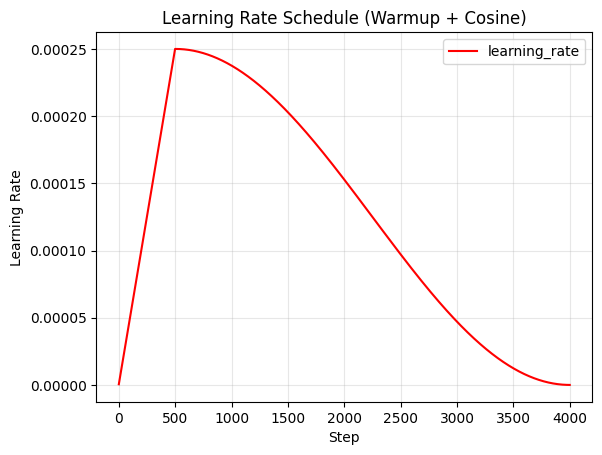

In [85]:
# Cosine Schedule 시각화
test_schedule = CosineSchedule(optimizer=None, train_steps=4000, warmup_steps=500,
                               max_lr=2.5e-4)
lrs = []
for _ in range(4000):
    lrs.append(test_schedule.step())

plt.plot(lrs, 'r-', label='learning_rate')
plt.xlabel('Step'); plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule (Warmup + Cosine)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()


In [86]:
# 모델 생성을 위한 라이브러리 설치
!pip install torchinfo

In [87]:
# 모델 생성
from torchinfo import summary

# 실제 SentencePiece vocab size 로 다시 설정
config.n_vocab = vocab.get_piece_size()   # 8007 (또는 32007 등)
config.i_pad = 0
config.n_seq = 128

print("config.n_vocab:", config.n_vocab)
print("config.n_seq  :", config.n_seq)

pre_train_model = build_model_pre_train(config)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pre_train_model.to(device)

enc_tokens_example = torch.randint(0, config.n_vocab, (4, config.n_seq), dtype=torch.long).to(device)
segments_example   = torch.randint(0, 2, (4, config.n_seq), dtype=torch.long).to(device)

summary(pre_train_model, input_data=(enc_tokens_example, segments_example))


config.n_vocab: 8007
config.n_seq  : 128


Layer (type:depth-idx)                                       Output Shape              Param #
PreTrainModel                                                [4, 2]                    --
├─BERT: 1-1                                                  [4, 128]                  --
│    └─SharedEmbedding: 2-1                                  [4, 128, 128]             1,024,896
│    └─PositionEmbedding: 2-2                                [4, 128, 128]             --
│    │    └─Embedding: 3-1                                   [4, 128, 128]             16,384
│    └─Embedding: 2-3                                        [4, 128, 128]             256
│    └─LayerNorm: 2-4                                        [4, 128, 128]             256
│    └─Dropout: 2-5                                          [4, 128, 128]             --
│    └─ModuleList: 2-6                                       --                        --
│    │    └─EncoderLayer: 3-2                                [4, 128, 128]        

In [88]:
epochs = 10
batch_size = 64

# 총 학습 step 수
train_steps = math.ceil(len(pre_train_inputs[0]) / batch_size) * epochs
print("epochs      :", epochs)
print("batch_size  :", batch_size)
print("train_steps :", train_steps)

# Adam → AdamW + weight_decay (BERT 권장)
# lr=0.0 으로 시작 — scheduler 가 매 step 마다 lr 을 직접 채워넣음
optimizer = optim.AdamW(pre_train_model.parameters(), lr=0.0,
                        betas=(0.9, 0.999), eps=1e-8, weight_decay=0.01)

learning_rate_scheduler = CosineSchedule(
    optimizer=optimizer,
    train_steps=train_steps,
    warmup_steps=max(100, train_steps // 10),
    max_lr=1e-4
)

loss_fn_nsp = nn.CrossEntropyLoss()
# MLM loss 는 위에서 정의한 lm_loss 함수를 사용 (ignore_index=0)


epochs      : 10
batch_size  : 64
train_steps : 14040


In [89]:
import os
os.makedirs("work", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# np.memmap → torch tensor (CPU에 두고 batch 별로 GPU 로 이동)
pre_train_inputs_t = [torch.from_numpy(np.asarray(x)) for x in pre_train_inputs]
pre_train_labels_t = [torch.from_numpy(np.asarray(x)) for x in pre_train_labels]

train_dataset = TensorDataset(
    pre_train_inputs_t[0],   # enc_tokens
    pre_train_inputs_t[1],   # segments
    pre_train_labels_t[0],   # labels_nsp
    pre_train_labels_t[1],   # labels_mlm
)
train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=(device.type == "cuda"),
)

pre_train_model.to(device)

history = {"nsp_loss": [], "mlm_loss": [], "nsp_acc": [], "mlm_acc": []}

for epoch in range(epochs):
    pre_train_model.train()
    total_loss = 0.0
    total_nsp_loss = 0.0
    total_mlm_loss = 0.0
    total_nsp_acc = 0.0
    total_mlm_acc = 0.0

    pbar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs}")
    for batch in pbar:
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch

        enc_tokens_batch  = enc_tokens_batch.to(device, dtype=torch.long, non_blocking=True)
        segments_batch    = segments_batch.to(device, dtype=torch.long, non_blocking=True)
        labels_nsp_batch  = labels_nsp_batch.to(device, dtype=torch.long, non_blocking=True)
        labels_mlm_batch  = labels_mlm_batch.to(device, dtype=torch.long, non_blocking=True)

        optimizer.zero_grad()

        # forward — raw logits 반환
        logits_nsp, logits_mlm = pre_train_model(enc_tokens_batch, segments_batch)

        # NSP: 일반 cross entropy (label: 0 or 1)
        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)

        # MLM: ignore_index=0 으로 mask 안 된 위치 제외
        loss_mlm = lm_loss(labels_mlm_batch, logits_mlm, ignore_index=0)

        loss = loss_nsp + loss_mlm

        loss.backward()
        # Gradient clipping (BERT 권장)
        torch.nn.utils.clip_grad_norm_(pre_train_model.parameters(), max_norm=1.0)
        optimizer.step()
        learning_rate_scheduler.step()       # ← lr 업데이트

        # metrics
        total_loss     += loss.item()
        total_nsp_loss += loss_nsp.item()
        total_mlm_loss += loss_mlm.item()

        nsp_acc = (logits_nsp.argmax(dim=-1) == labels_nsp_batch).float().mean().item()
        mlm_acc_v = lm_acc(labels_mlm_batch, logits_mlm, ignore_index=0).item()
        total_nsp_acc += nsp_acc
        total_mlm_acc += mlm_acc_v

        pbar.set_postfix(
            nsp_l=f"{loss_nsp.item():.3f}",
            mlm_l=f"{loss_mlm.item():.3f}",
            mlm_a=f"{mlm_acc_v:.3f}",
            lr=f"{optimizer.param_groups[0]['lr']:.2e}",
        )

    n = len(train_dataloader)
    history["nsp_loss"].append(total_nsp_loss / n)
    history["mlm_loss"].append(total_mlm_loss / n)
    history["nsp_acc"].append(total_nsp_acc / n)
    history["mlm_acc"].append(total_mlm_acc / n)

    print(f"[Epoch {epoch+1}/{epochs}] "
          f"NSP loss={history['nsp_loss'][-1]:.4f}  acc={history['nsp_acc'][-1]:.4f}  | "
          f"MLM loss={history['mlm_loss'][-1]:.4f}  acc={history['mlm_acc'][-1]:.4f}")

    torch.save(pre_train_model.state_dict(), f"work/bert_pre_train_epoch_{epoch+1}.pt")


Epoch 1/10:   0%|          | 0/1404 [00:00<?, ?it/s]

[Epoch 1/10] NSP loss=0.6394  acc=0.5861  | MLM loss=8.0487  acc=0.0209


Epoch 2/10:   0%|          | 0/1404 [00:00<?, ?it/s]

[Epoch 2/10] NSP loss=0.6181  acc=0.5897  | MLM loss=7.5289  acc=0.0297


Epoch 3/10:   0%|          | 0/1404 [00:00<?, ?it/s]

...

[Epoch 8/10] NSP loss=0.5956  acc=0.5933  | MLM loss=7.4370  acc=0.0328


Epoch 9/10:   0%|          | 0/1404 [00:00<?, ?it/s]

[Epoch 9/10] NSP loss=0.5952  acc=0.5924  | MLM loss=7.4317  acc=0.0330


Epoch 10/10:   0%|          | 0/1404 [00:00<?, ?it/s]

[Epoch 10/10] NSP loss=0.5952  acc=0.5941  | MLM loss=7.4299  acc=0.0332


       nsp_loss  mlm_loss   nsp_acc   mlm_acc
epoch                                        
1      0.639435  8.048741  0.586118  0.020942
2      0.618094  7.528948  0.589690  0.029670
3      0.600669  7.513098  0.586917  0.029659
4      0.600083  7.492750  0.586365  0.029567
5      0.598363  7.474437  0.587800  0.029994
6      0.597512  7.458684  0.588263  0.031132
7      0.595769  7.445719  0.593539  0.032321
8      0.595614  7.436953  0.593251  0.032834
9      0.595246  7.431722  0.592428  0.032997
10     0.595232  7.429948  0.594086  0.033155


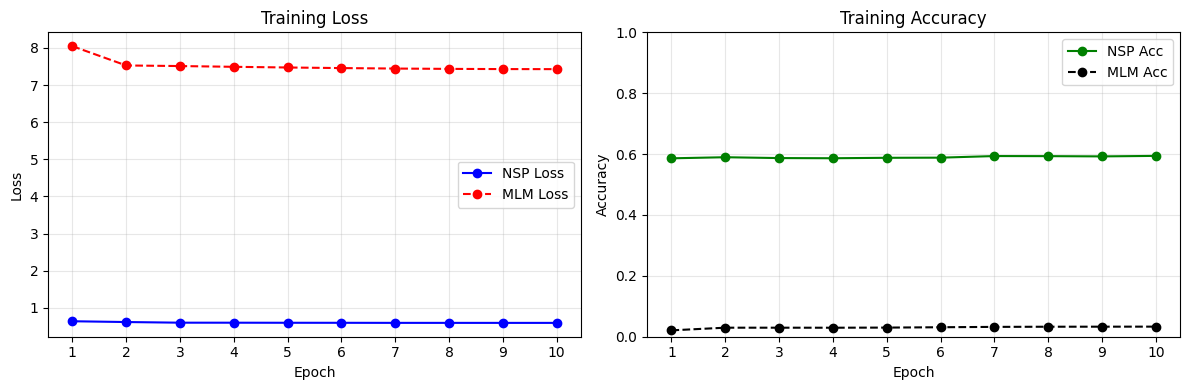

In [90]:
import pandas as pd

if len(history["nsp_loss"]) == 0:
    raise RuntimeError("history 가 비어 있습니다. 학습 셀이 정상 실행됐는지 확인하세요.")

history_df = pd.DataFrame(history)
history_df.index = range(1, len(history_df) + 1)
history_df.index.name = "epoch"
print(history_df)

x = history_df.index.to_list()
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(x, history_df["nsp_loss"], 'b-o',  label="NSP Loss")
plt.plot(x, history_df["mlm_loss"], 'r--o', label="MLM Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.xticks(x)
plt.legend(); plt.grid(True, alpha=0.3)
plt.title("Training Loss")

plt.subplot(1, 2, 2)
plt.plot(x, history_df["nsp_acc"], 'g-o',  label="NSP Acc")
plt.plot(x, history_df["mlm_acc"], 'k--o', label="MLM Acc")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.xticks(x)
plt.ylim(0, 1); plt.legend(); plt.grid(True, alpha=0.3)
plt.title("Training Accuracy")

plt.tight_layout()
plt.show()
